# NLP and Sequence Modeling Mini Project

## Objective

The objective of this project is to build a basic NLP pipeline using traditional machine learning and sequence modeling techniques for sentiment classification.

This project includes:
- Dataset understanding
- Text preprocessing
- Text vectorization
- Baseline machine learning model
- LSTM sequence modeling
- Attention and transformer reflection

In [52]:
print("NLP Project Started Successfully")

NLP Project Started Successfully


# Import Required Libraries

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

print("Libraries Imported Successfully")

Libraries Imported Successfully


# Task 1: Dataset Understanding

In this section, we analyze the dataset by checking:
- Number of records
- Target labels/classes
- Sample records
- Average text length
- Class distribution

In [54]:
# Load Dataset

df = pd.read_csv("customer_support_text_classification.csv")

print("Dataset Loaded Successfully")

df.head()

Dataset Loaded Successfully


,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


In [55]:
# Dataset Shape
print("Dataset Shape:", df.shape)

# Number of Records
print("Number of Records:", len(df))

# Column Names
print("\nColumns in Dataset:")
print(df.columns)

# Target Labels
print("\nUnique Sentiment Labels:")
print(df['sentiment_label'].unique())

# Class Distribution
print("\nClass Distribution:")
print(df['sentiment_label'].value_counts())

# Average Word Count
average_words = df['word_count'].mean()

print("\nAverage Word Count:", average_words)

# Sample Records
print("\nSample Records:")
df[['customer_message', 'sentiment_label']].head()

Dataset Shape: (1500, 6)
Number of Records: 1500

Columns in Dataset:
Index(['ticket_id', 'channel', 'customer_message', 'sentiment_label',
       'word_count', 'urgent_flag'],
      dtype='str')

Unique Sentiment Labels:
<StringArray>
['neutral', 'positive', 'negative']
Length: 3, dtype: str

Class Distribution:
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64

Average Word Count: 12.722666666666667

Sample Records:


,customer_message,sentiment_label
0,I need information about the payment process. ...,neutral
1,I need information about the payment process.,neutral
2,The refund process was fast and convenient. I ...,positive
3,My refund is still pending and this experience...,negative
4,Please tell me how to update my account details.,neutral


## Class Distribution Visualization

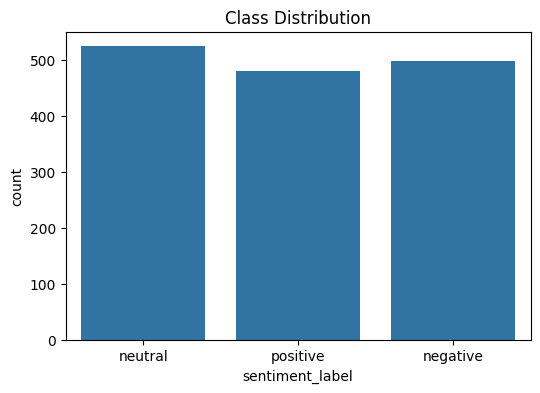

In [56]:
plt.figure(figsize=(6,4))

sns.countplot(x='sentiment_label', data=df)

plt.title("Class Distribution")

plt.savefig("results/class_distribution.png")

plt.show()

# Task 2: Text Preprocessing

The text data is cleaned using:
- Lowercasing
- Removing special characters
- Tokenization
- Stopword handling
- Padding sequences

In [57]:
# Text Cleaning Function

def clean_text(text):
    
    text = text.lower()
    
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    return text

In [58]:
df['cleaned_text'] = df['customer_message'].apply(clean_text)

df[['customer_message', 'cleaned_text']].head()

,customer_message,cleaned_text
0,I need information about the payment process. ...,i need information about the payment process m...
1,I need information about the payment process.,i need information about the payment process
2,The refund process was fast and convenient. I ...,the refund process was fast and convenient i a...
3,My refund is still pending and this experience...,my refund is still pending and this experience...
4,Please tell me how to update my account details.,please tell me how to update my account details


## Tokenization

In [59]:
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df['cleaned_text'])

sequences = tokenizer.texts_to_sequences(df['cleaned_text'])

print(sequences[:5])

[[4, 29, 136, 39, 1, 90, 33, 3, 6, 7, 2, 10, 12, 8, 13, 8, 14], [4, 29, 136, 39, 1, 90, 33], [1, 28, 33, 11, 57, 5, 58, 4, 30, 1, 31, 22], [3, 28, 2, 120, 121, 5, 20, 52, 2, 122, 3, 6, 7, 2], [10, 63, 64, 65, 9, 48, 3, 45, 66]]


## Padding Sequences

In [60]:
max_length = 20

X_seq = pad_sequences(sequences, maxlen=max_length)

print(X_seq.shape)

(1500, 20)


## Label Encoding

In [61]:
label_mapping = {
    'negative': 0,
    'neutral': 1,
    'positive': 2
}

y = df['sentiment_label'].map(label_mapping)

print(y.head())

0    1
1    1
2    2
3    0
4    1
Name: sentiment_label, dtype: int64


# Task 3: Text Vectorization

Text must be converted into numerical vectors because machine learning models cannot understand raw text directly.

TF-IDF and tokenizer-based sequences are used to transform text into numerical representations.

In [62]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['cleaned_text'])

print(X.shape)

(1500, 180)


# Task 4: Baseline Model

A Logistic Regression model is trained using TF-IDF vectorized text data.

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [64]:
model = LogisticRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [65]:
model = LogisticRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


## Model Evaluation

In [66]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       109
           1       1.00      1.00      1.00       104
           2       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



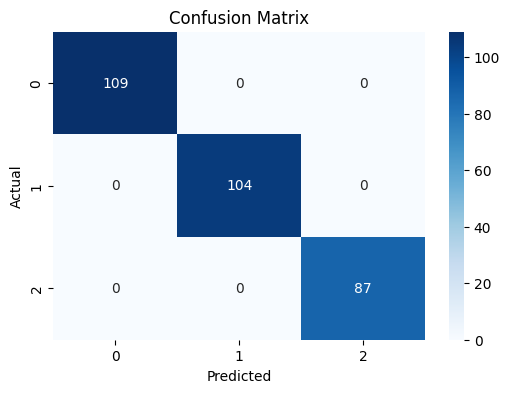

In [67]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig("results/confusion_matrix.png")

plt.show()

In [68]:
report = classification_report(y_test, y_pred)

with open("results/model_evaluation.txt", "w") as f:
    f.write(report)

print("Model Evaluation Saved Successfully")

Model Evaluation Saved Successfully


## Saving Sample Predictions

In [69]:
sample_predictions = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10]
})

sample_predictions.to_csv(
    "results/sample_predictions.txt",
    index=False
)

print(sample_predictions)

   Actual  Predicted
0       1          1
1       2          2
2       1          1
3       0          0
4       0          0
5       0          0
6       0          0
7       1          1
8       0          0
9       0          0


# Task 5: LSTM Sequence Modeling

The sequence model processes text in sequential order.

Architecture:
1. Input Sequence
2. Embedding Layer
3. LSTM Layer
4. Dense Output Layer

Loss Function:
- Sparse Categorical Crossentropy

Evaluation Metric:
- Accuracy

In [70]:
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq,
    y,
    test_size=0.2,
    random_state=42
)

In [71]:
lstm_model = Sequential()

lstm_model.add(Embedding(input_dim=5000, output_dim=64))

lstm_model.add(LSTM(64))

lstm_model.add(Dense(3, activation='softmax'))

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [72]:
history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=3,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/3
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.6219 - loss: 0.9435 - val_accuracy: 0.9500 - val_loss: 0.5114
Epoch 2/3
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9927 - loss: 0.1545 - val_accuracy: 1.0000 - val_loss: 0.0263
Epoch 3/3
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 1.0000 - loss: 0.0053 - val_accuracy: 1.0000 - val_loss: 0.0024


# Task 6: Attention and Transformer Reflection

## Why RNNs struggle with long-term dependencies

RNNs process text sequentially, but they may forget earlier information when sequences become long.

## How LSTMs help with memory

LSTMs use memory cells and gates to retain important information for longer periods.

## What attention solves

Attention allows the model to focus on important words in the sequence instead of treating all words equally.

## Why transformers are important

Transformers process text more efficiently using attention mechanisms. They are faster, handle long dependencies better, and power modern Generative AI systems like ChatGPT and BERT.

# Conclusion

In this project, we explored both traditional NLP techniques and deep learning-based sequence models.

TF-IDF with Logistic Regression provided strong baseline performance, while LSTM demonstrated how sequence models learn contextual information from text data.

We also understood the importance of embeddings, attention mechanisms, and transformers in modern NLP and Generative AI systems.

# Conclusion

In this project, a complete NLP pipeline was developed for customer support text classification.

The project included:
- Text preprocessing
- TF-IDF vectorization
- Logistic Regression baseline model
- Sequence modeling using LSTM
- Model evaluation using accuracy and classification report

The project also explored attention mechanisms and transformers to understand modern NLP systems and Generative AI.

The results showed that sequence-based models help capture contextual information more effectively than traditional methods.